#EJERCICIOS DE ENTROPÍA
##Objetivo
Obtener e interpretar valores relacionados con la entropía en bases de datos.
##Librerías
A continuación instalaremos o cargaremos las librerías necesarias para nuestro trabajo: readxl para leer archivos de Excel, psych para descriptiva, e infotheo para el cálculo de la entropía.

In [1]:
install.packages(c("psych","infotheo"))
library(psych)
library(infotheo)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘mnormt’




Leemos el archivo:




In [14]:
cartera<-read.csv("cartera.csv", header=TRUE, sep=";", dec=",")

Miramos la estructura y hacemos ajustes a la misma

In [15]:
str(cartera)

'data.frame':	852 obs. of  9 variables:
 $ MESES             : int  41 27 40 41 24 41 39 43 24 36 ...
 $ tipoips           : int  3 1 1 1 2 2 1 1 1 1 ...
 $ igualowner        : int  17 10 15 15 2 5 20 12 3 0 ...
 $ yearsadress       : int  12 6 14 14 0 5 9 11 4 13 ...
 $ ventasmesaverage  : int  176 31 55 120 28 25 67 38 19 25 ...
 $ pasivo_sobre_venta: num  9.3 17.3 5.5 2.9 17.3 10.2 30.6 3.6 24.4 19.7 ...
 $ carteraA          : num  11.36 1.36 0.86 2.66 1.79 ...
 $ carteraB          : num  5.01 4 2.17 0.82 3.06 ...
 $ retrasos          : int  1 0 0 0 1 0 0 0 1 0 ...


In [16]:
cartera$retrasos<-as.factor(cartera$retrasos)
cartera$tipoips<-as.factor(cartera$tipoips)

Miremos la tabla de frecuencia de tipo IPS

In [5]:
table(cartera$tipoips)


  1   2   3   4   5 
462 235 101  49   5 

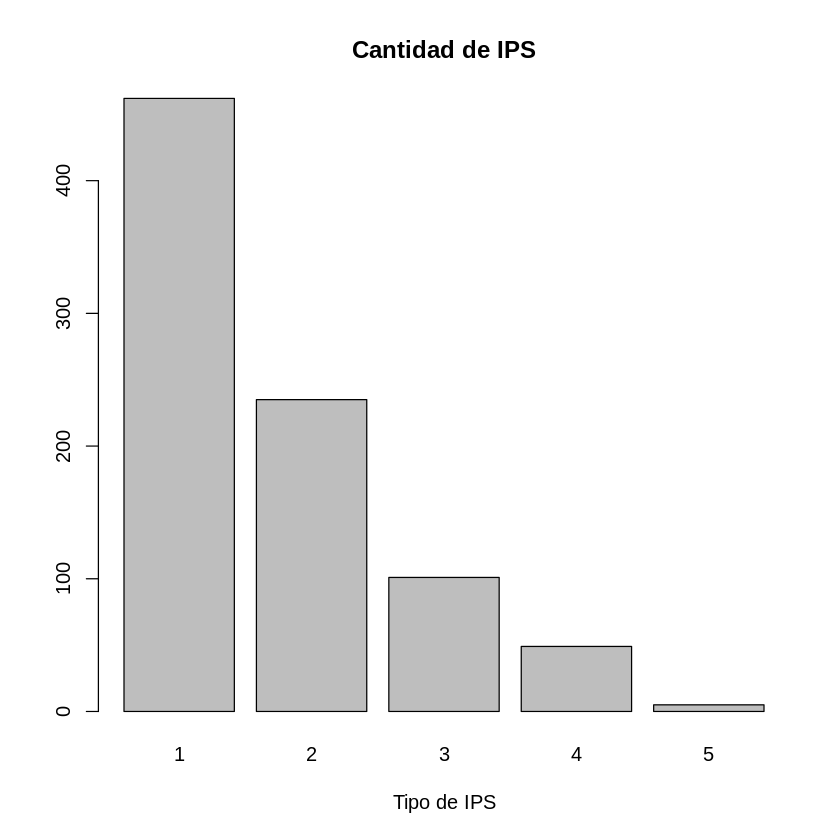

In [18]:
tabla1<-table(cartera$tipoips)
barplot(tabla1, main="Cantidad de IPS", xlab="Tipo de IPS")

In [19]:
prop.table(tabla1)


          1           2           3           4           5 
0.542253521 0.275821596 0.118544601 0.057511737 0.005868545 

Esta variable marca la complejidad (tamaño) de la IPS en valores de 1 a 5.  En general se presenta una estructura esperada: más clientes pequeños (de baja complejidad) y unos pocos clientes grandes, lo cual hace que se reduzca la entropía.
Una medida interesante para una variable categórica es su entropia, que puede indicar qué tanta dispersión/uniformidad hay entre las categorías. Veamos:




In [7]:
entropia_A<-entropy(cartera$tipoips)
natstobits(entropia_A)
entropia_A

[1] 1.636471

[1] 1.134315

y la entropía maxima esperada era:

In [22]:
log2(nlevels(cartera$tipoips))

[1] 2.321928

Ahora cruzemos las dos variables:

In [20]:
table(cartera$tipoips,cartera$retrasos)

   
      0   1
  1 377  85
  2 174  61
  3  70  31
  4  34  15
  5   4   1

In [24]:
attach(cartera)
install.packages("gmodels")
library("gmodels")
CrossTable(tipoips, retrasos)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gtools’, ‘gdata’





 
   Cell Contents
|-------------------------|
|                       N |
| Chi-square contribution |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  852 

 
             | retrasos 
     tipoips |         0 |         1 | Row Total | 
-------------|-----------|-----------|-----------|
           1 |       377 |        85 |       462 | 
             |     1.081 |     3.691 |           | 
             |     0.816 |     0.184 |     0.542 | 
             |     0.572 |     0.440 |           | 
             |     0.442 |     0.100 |           | 
-------------|-----------|-----------|-----------|
           2 |       174 |        61 |       235 | 
             |     0.332 |     1.133 |           | 
             |     0.740 |     0.260 |     0.276 | 
             |     0.264 |     0.316 |           | 
             |     0.204 |     0.072 |           | 
-------------|-----------|-----------|------

Y finalmente un gráfico con residuales de pearson:

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘zoo’, ‘lmtest’


Loading required package: grid



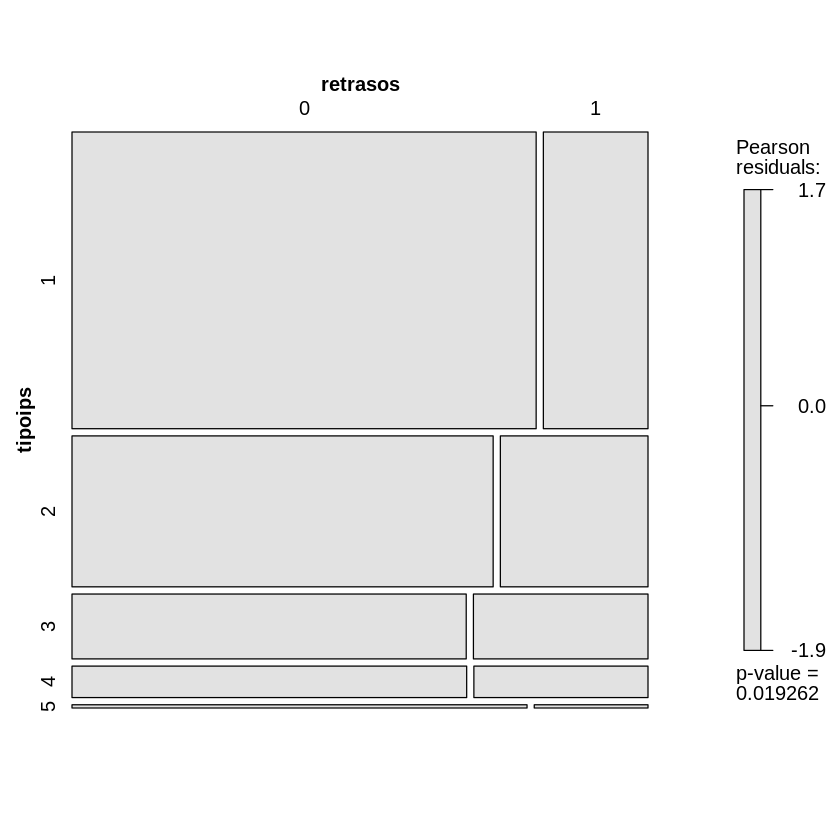

In [25]:
install.packages("vcd")
library("vcd")
mosaic(~tipoips + retrasos,data=cartera,
       legend=TRUE, shade=TRUE)

No parece haber mucha asociación entre las dos variables. Pero mirémoslo desde el punto de vista de la entropía.

In [10]:
entroy<-natstobits(entropy(cartera$retrasos))
entroy_dadox<-natstobits(condentropy(cartera$retrasos,cartera$tipoips))
infogain<-entroy-entroy_dadox
entroy
entroy_dadox
infogain

[1] 0.7719057

[1] 0.7621154

[1] 0.009790264

La ganancia o aprendizaje que tengo de los retrasos a partir del tipo de IPS es muy poca. Por tanto su *información mutua* (que es el mismo valor) también es poca

In [12]:
natstobits(mutinformation(cartera$retrasos,cartera$tipoips))

[1] 0.009790264

No parece haber una relación entre el tamaño/complejidad de la IPS y si se retrasa o no. Veamos el estadístico básico adecuado, que nos indica que el resultado está muy cerca a los límites clásicos de la significancia:






In [26]:
chisq.test(tipoips,retrasos)

Warning message in chisq.test(tipoips, retrasos):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  tipoips and retrasos
X-squared = 11.756, df = 4, p-value = 0.01926


También puedo calcular la entropía conjunta a partir de estas medidas:

In [27]:
entro_conjunta<-entroy+entroy_dadox
entro_conjunta

[1] 1.534021

La entropía directa es interpretable en términos de transmisión de información (i.e, bits o nats necesarios para comunicar la variable). Unas medidas más fácilmente interpretables serían la entropía relativa a su máximo y el número efectivo de especies (que puede leerse como el número de categorías que debiéramos tener y puede guiar la agrupación de categorías)

In [8]:
##para que funcione la ecuación se debe trabajar con factores
entropia_relativa<-entropy(cartera$tipoips)/log(nlevels(cartera$tipoips))
especies<-exp(entropy(cartera$tipoips))
entropia_relativa
especies

[1] 0.7047897

[1] 3.109044

En este ejemplo hemos hecho un repaso rápido del funcionamiento y cálculo de algunos elementos de la entropía.